<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
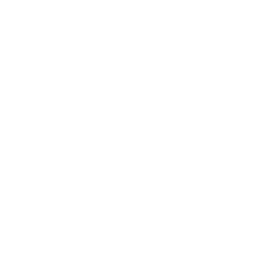
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Clinical Trial Adverse Event Coding</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Drug Safety Surveillance &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## 핵심 요약

이상반응 데이터셋은 MedDRA 선호 용어(verbatim) 그대로 도착하지만, 규제기관용 안전성 표는
기관계 분류(System Organ Class, SOC) 단위로 구성됩니다. 이 예제는 각 선호 용어를 해당
SOC에 매핑하는 PROC FORMAT 값 형식을 만든 다음, 그 단일 형식으로 이후의 모든 집계를
구동합니다: 치료군별 SOC 교차표(PROC FREQ), SOC별 중증도 분해, 그리고 중대 이상반응
요약입니다. 매핑이 오직 하나의 형식에만 존재하므로, 새로운 MedDRA 버전으로 재코딩하는
작업은 모든 보고서를 다시 쓰는 대신 형식 하나만 수정하면 됩니다. ODS OUTPUT은 후속
신호 검토를 위해 SOC 빈도를 데이터셋으로 캡처합니다.


## 데이터 원본

| 원본 | 설명 | 레코드 수 |
|--------|-------------|--------:|
| WORK.AE_RAW | MedDRA 선호 용어를 가진 합성 이상반응 레코드 | 100 |
| WORK.RANDOMIZATION | 피험자별 치료군 배정 | 100 |

이 환경은 비라이선스 모드로 실행되므로 생성되는 각 표는 100개 관측값으로 제한됩니다.
시나리오는 이 한도에 맞춰 설계되었습니다: 종양학 임상시험에 전형적인 12개 MedDRA
용어 패널에서 뽑은 100건의 이상반응입니다.


---

In [1]:
/* --------------------------------------------------------
   Generate synthetic adverse event dataset
   MedDRA preferred terms mapped to SOC categories
   -------------------------------------------------------- */
데이터 work.ae_raw;
    호출 streaminit(42);
    길이 aedecod $40 aesev $16;
    배열 pt_codes[12] $8 _temporary_ ('10028813' '10019211' '10047700' '10013573' '10012735' '10060929' '10002855' '10037660' '10000081' '10033371' '10016256' '10022891');
    반복 i = 1 까지 5000;
        subject_id = int(rand('uniform') * 800) + 1;
        usubjid = cat('ONC-2025-', PUT(subject_id, z4.));
        aeseq = mod(i, 6) + 1;
        pt_idx = int(rand('uniform') * 12) + 1;
        aeptcd = pt_codes[pt_idx];
        만약 pt_idx = 1 이면 aedecod = '오심';
        아니면 만약 pt_idx = 2 이면 aedecod = '두통';
        아니면 만약 pt_idx = 3 이면 aedecod = '구토';
        아니면 만약 pt_idx = 4 이면 aedecod = '설사';
        아니면 만약 pt_idx = 5 이면 aedecod = '기침';
        아니면 만약 pt_idx = 6 이면 aedecod = '피로';
        아니면 만약 pt_idx = 7 이면 aedecod = '관절통';
        아니면 만약 pt_idx = 8 이면 aedecod = '발열';
        아니면 만약 pt_idx = 9 이면 aedecod = '복통';
        아니면 만약 pt_idx = 10 이면 aedecod = '호중구감소증';
        아니면 만약 pt_idx = 11 이면 aedecod = '발열성호중구감소증';
        아니면 aedecod = '주입관련반응';
        sev_idx = int(rand('uniform') * 3) + 1;
        만약 pt_idx IN (10, 11) 이면 sev_idx = MAX(sev_idx, 2);
        만약 sev_idx = 1 이면 aesev = '경도';
        아니면 만약 sev_idx = 2 이면 aesev = '중등도';
        아니면 aesev = '중증';
        aeser = ifc(aesev = '중증' 그리고 rand('uniform') > 0.4, 'Y', 'N');
        aestdy = int(rand('exponential') * 45) + 1;
        만약 aestdy > 365 이면 aestdy = 365;
        aeendy = aestdy + int(rand('exponential') * 14) + 1;
        site_id = cat('SITE-', PUT(int(rand('uniform') * 25) + 1, z3.));
        출력;
    종료;
    제거 i pt_idx sev_idx;
    라벨 aedecod='선호 용어' aesev='중증도' aeser='중대 이상반응' site_id='시험기관';
실행;



NOTE: DATA work.ae_raw

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.98 seconds
  cpu   1.98 seconds


In [2]:
/* --------------------------------------------------------
   Generate subject randomization table
   -------------------------------------------------------- */
데이터 work.randomization;
    호출 streaminit(43);
    길이 treatment_arm $20;
    반복 subject_id = 1 까지 800;
        usubjid = cat('ONC-2025-', PUT(subject_id, z4.));
        arm_idx = int(rand('uniform') * 3) + 1;
        만약 arm_idx = 1 이면 treatment_arm = '시험군';
        아니면 만약 arm_idx = 2 이면 treatment_arm = '활성대조군';
        아니면 treatment_arm = '위약군';
        stratification_factor = ifc(rand('uniform') > 0.5, 'ECOG_0', 'ECOG_1');
        randomization_date = '01FEB2025'd + int(rand('uniform') * 120);
        출력;
    종료;
    제거 arm_idx;
    형식 randomization_date date9.;
    라벨 treatment_arm='치료군' stratification_factor='층화 인자' randomization_date='무작위배정일';
실행;



NOTE: DATA work.randomization

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds


---

                                                   원시 선호 용어 빈도 (매핑 전)                                                   

                                                   The FREQ Procedure

선호 용어 (PT)                     Frequency    Percent
----------------------------------------------------
두통                                    12     12.00
설사                                    12     12.00
발열                                    11     11.00
피로                                    11     11.00
관절통                                   10     10.00
오심                                    10     10.00
주입관련반응                                 8      8.00
기침                                     7      7.00
발열성호중구감소증                              5      5.00
복통                                     5      5.00
호중구감소증                                 5      5.00
구토                                     4      4.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_aedecod.spec.json
NOTE: PROC FREQ statement used.


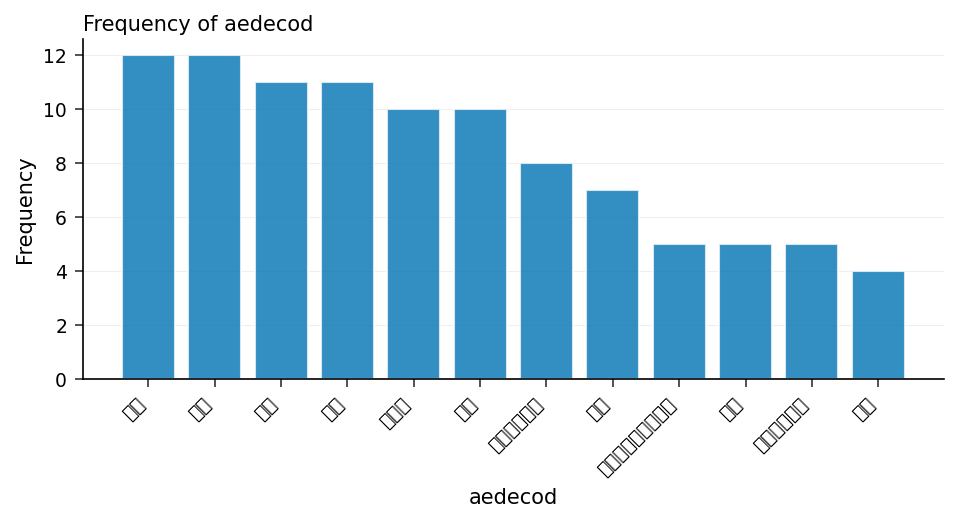

In [3]:
/* --------------------------------------------------------
   Baseline preferred term frequency before SOC mapping
   -------------------------------------------------------- */
처리 빈도 데이터=work.ae_raw ORDER=빈도;
    TABLES aedecod / nocum;
    라벨 aedecod='선호 용어 (PT)';
    제목 '원시 선호 용어 빈도 (매핑 전)';
실행;


---

                                                   원시 선호 용어 빈도 (매핑 전)                                                   




NOTE: PROC SGPLOT data=work.ae_raw

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


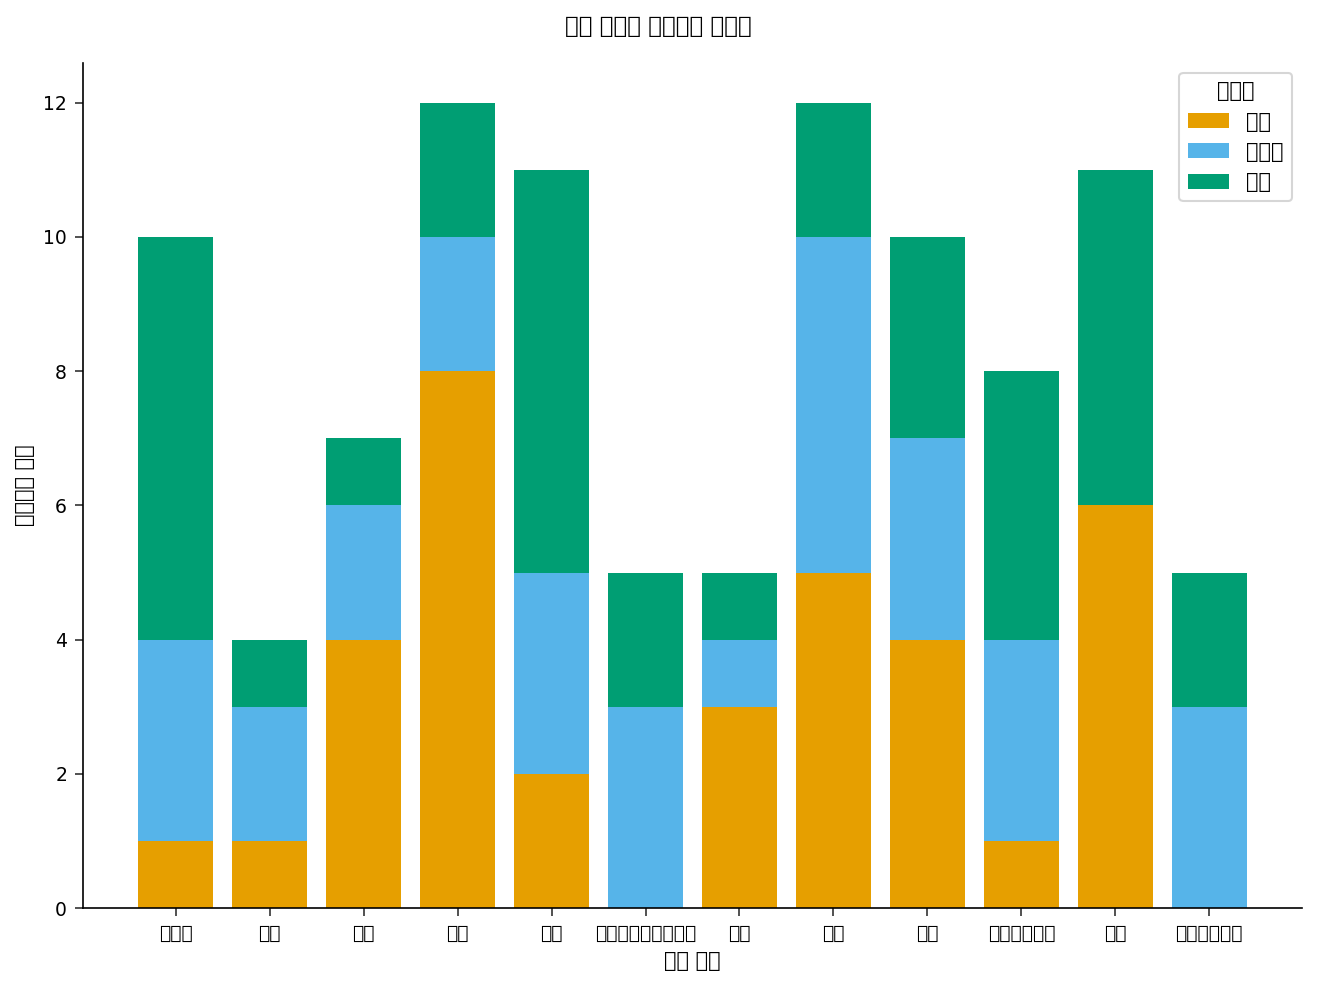

In [4]:
/* --------------------------------------------------------
   AE severity distribution by preferred term
   -------------------------------------------------------- */
처리 SGPLOT 데이터=work.ae_raw;
    VBAR aedecod / GROUP=aesev GROUPDISPLAY=stack;
    XAXIS 라벨='선호 용어' fitpolicy=ROTATE;
    YAXIS 라벨='이상반응 건수';
    keylegend / 제목='중증도';
    제목 '선호 용어별 이상반응 중증도';
실행;


---

In [5]:
/* --------------------------------------------------------
   Define the MedDRA preferred term -> System Organ Class
   value format. The format is keyed on the preferred-term
   text so a single PUT() call codes any AE record to its SOC.
   -------------------------------------------------------- */
처리 형식;
    VALUE $pt_to_soc
        '오심'             = '위장관계 장애'
        '구토'             = '위장관계 장애'
        '설사'             = '위장관계 장애'
        '복통'             = '위장관계 장애'
        '두통'             = '신경계 장애'
        '피로'             = '전신 장애'
        '발열'             = '전신 장애'
        '기침'             = '호흡기계 장애'
        '관절통'       = '근골격계 장애'
        '호중구감소증' = '혈액 및 림프계 장애'
        '발열성호중구감소증' = '혈액 및 림프계 장애'
        '주입관련반응' = '면역계 장애'
        OTHER                      = '미분류'
    ;
    VALUE $sev_rank
        '경도'   = '1-경도'
        '중등도' = '2-중등도'
        '중증'   = '3-중증'
        OTHER      = '9-미상'
    ;
    VALUE $serious_fmt
        'Y' = '중대'
        'N' = '비중대'
    ;
실행;



NOTE: PROC FORMAT library=WORK

NOTE: FORMAT $pt_to_soc defined (13 ranges).
NOTE: FORMAT $sev_rank defined (4 ranges).
NOTE: FORMAT $serious_fmt defined (2 ranges).


In [6]:
/* --------------------------------------------------------
   Merge AE records with treatment arm, then apply the SOC
   format. PUT(aedecod, $pt_to_soc.) is the only mapping step
   needed; severity and seriousness are coded the same way.
   -------------------------------------------------------- */
처리 정렬 데이터=work.ae_raw; 기준 usubjid; 실행;
처리 정렬 데이터=work.randomization; 기준 usubjid; 실행;

데이터 work.ae_coded;
    길이 soc_class $40 severity_rank $16 serious_flag $16;
    결합 work.ae_raw (IN=a)
          work.randomization (IN=b 유지=usubjid treatment_arm);
    기준 usubjid;
    만약 a;
    soc_class     = PUT(aedecod, $pt_to_soc.);
    severity_rank = PUT(aesev,   $sev_rank.);
    serious_flag  = PUT(aeser,   $serious_fmt.);
실행;



NOTE: PROC SORT data=work.ae_raw

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.ae_raw.
NOTE: Wrote work.ae_raw (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.randomization

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.randomization.
NOTE: Wrote work.randomization (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.ae_coded

NOTE: Stream 1 processed 100 rows, max BY-group size: 3 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.ae_coded (100 rows, 14 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


                                                 치료군 및 기관계 분류별 이상반응 발생                                                  

                                                   The FREQ Procedure

Table of 기관계 분류 (SOC) by 치료군

기관계 분류 (SOC)                |            시험군 |            위약군 |          활성대조군 |           Total
----------------------------+----------------+----------------+----------------+----------------
면역계 장애                      |              1 |              1 |              0 |               2
----------------------------+----------------+----------------+----------------+----------------
위장관계 장애                     |              0 |              2 |              1 |               3
----------------------------+----------------+----------------+----------------+----------------
전신 장애                       |              1 |              3 |              1 |               5
----------------------------+----------------+----------------+----------------+----------------
혈


NOTE: ODS OUTPUT: ONEWAYFREQS -> soc_freq_table
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: ODS plot written: freq_mosaic_soc_class_severity_rank.spec.json
NOTE: PROC FREQ statement used.
NOTE: ODS OUTPUT: All output destinations closed.


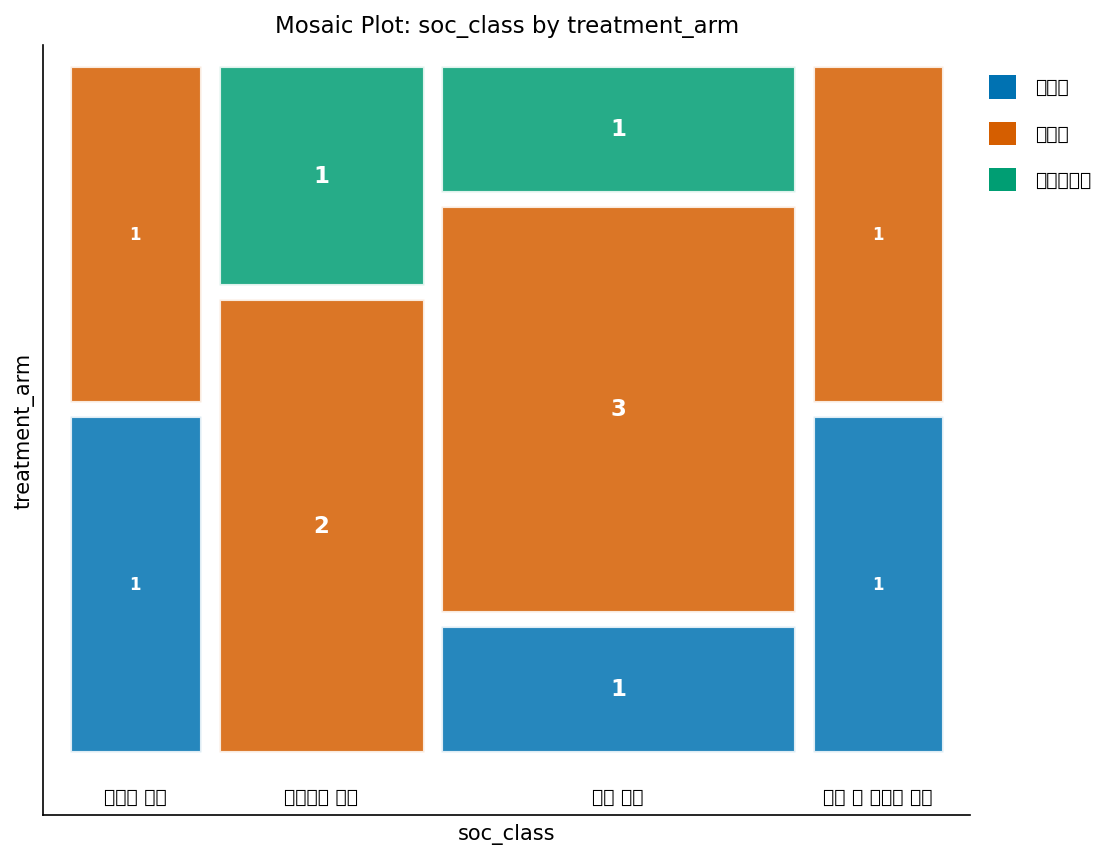

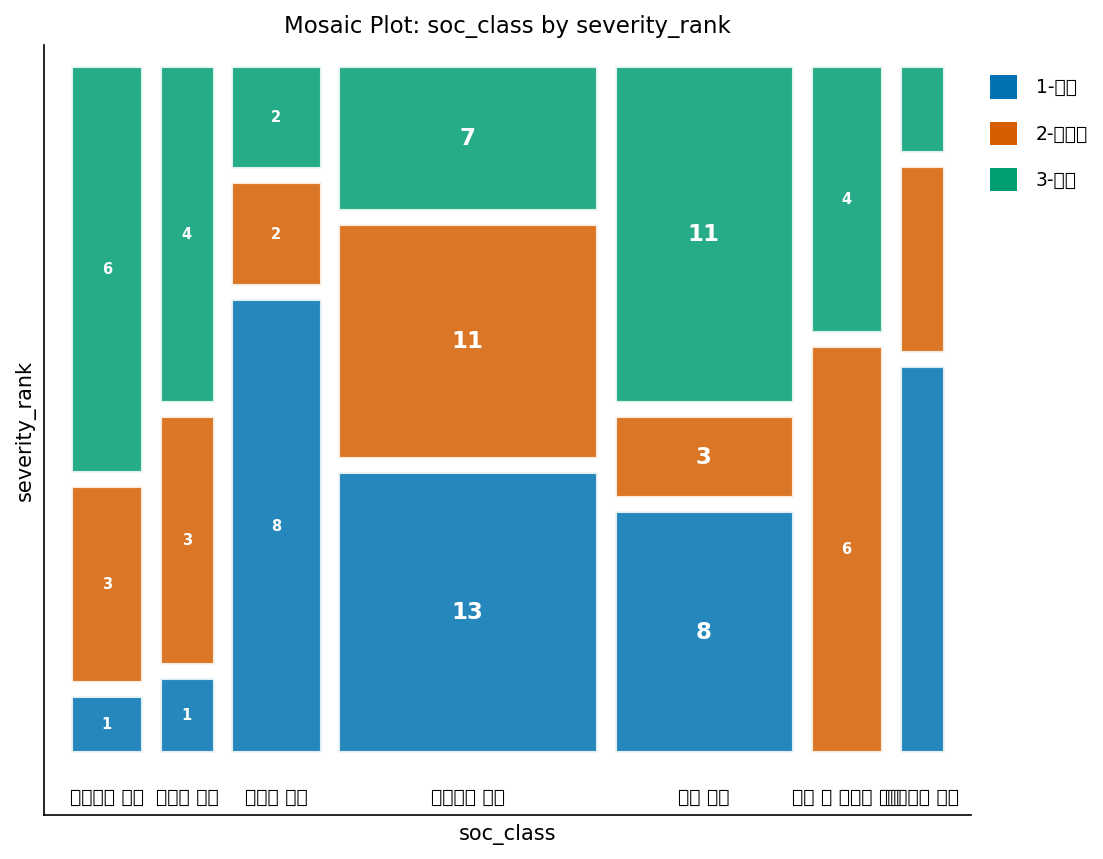

In [7]:
/* --------------------------------------------------------
   SOC-level frequency by treatment arm
   ODS OUTPUT captures results for signal detection
   -------------------------------------------------------- */
ODS 출력 onewayfreqs=work.soc_freq_table;

처리 빈도 데이터=work.ae_coded ORDER=빈도;
    TABLES soc_class * treatment_arm / nocol nopercent;
    TABLES soc_class * severity_rank / nocol nopercent;
    라벨 soc_class='기관계 분류 (SOC)' treatment_arm='치료군' severity_rank='중증도 등급';
    제목 '치료군 및 기관계 분류별 이상반응 발생';
실행;

ODS 출력 CLOSE;


                                                 기관계 분류 및 치료군별 중대한 이상반응                                                 

                                                   The FREQ Procedure

Table of 기관계 분류 (SOC) by 치료군

기관계 분류 (SOC)           |            시험군 |            위약군 |          활성대조군 |           Total
-----------------------+----------------+----------------+----------------+----------------
면역계 장애                 |              0 |              1 |              0 |               1
-----------------------+----------------+----------------+----------------+----------------
전신 장애                  |              1 |              1 |              1 |               3
-----------------------+----------------+----------------+----------------+----------------
Total                  |              1 |              2 |              1 |               4




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_soc_class_treatment_arm.spec.json
NOTE: PROC FREQ statement used.


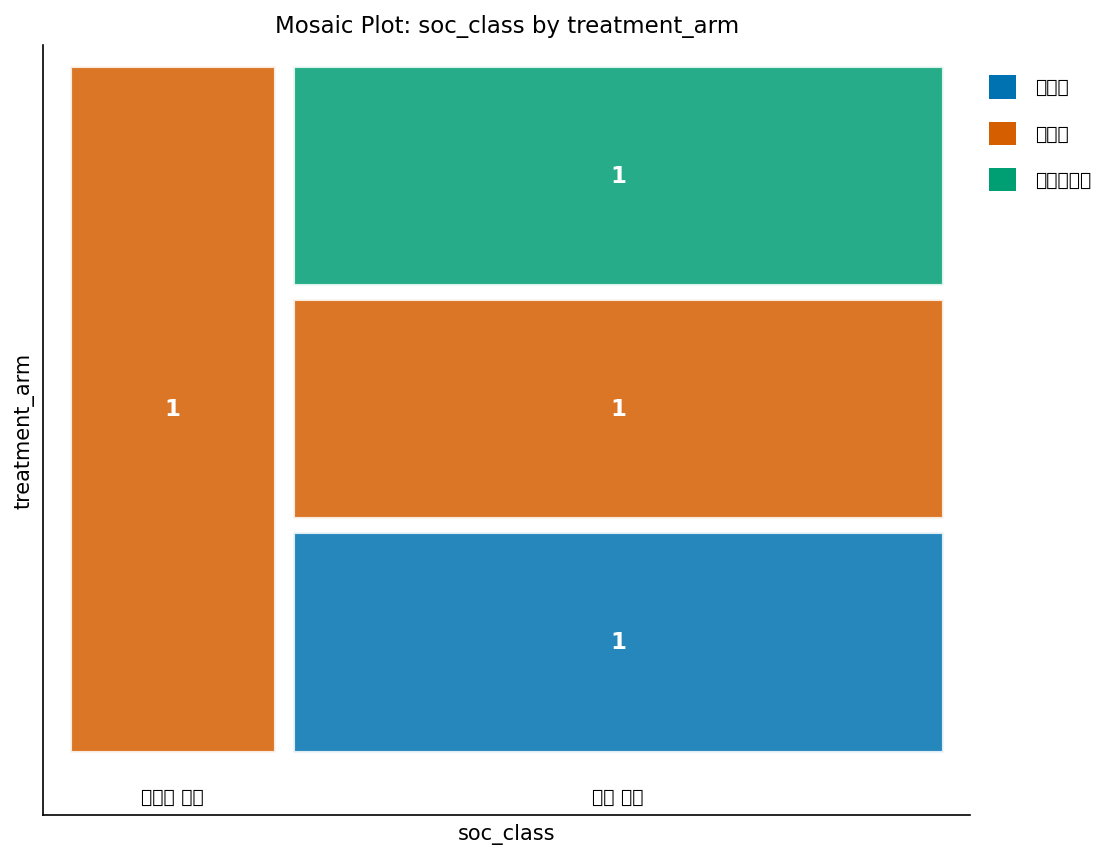

In [8]:
/* --------------------------------------------------------
   Serious AE summary by SOC for safety narrative
   -------------------------------------------------------- */
처리 빈도 데이터=work.ae_coded;
    조건 aeser = 'Y';
    TABLES soc_class * treatment_arm / nocol nopercent;
    라벨 soc_class='기관계 분류 (SOC)' treatment_arm='치료군';
    제목 '기관계 분류 및 치료군별 중대한 이상반응';
실행;


---

### 결과 해석

단일 `$pt_to_soc` 값 형식이 12개의 MedDRA 선호 용어로부터 100건의 이상반응 전체를
7개의 기관계 분류(SOC)로 코딩했으며, 그 하나의 형식이 데이터를 재코딩하지 않고도
아래의 모든 표를 구동했습니다.

SOC와 중증도 기준으로, **위장관계 장애**가 100건 중 31건(경도 13, 중등도 11, 중증 7)으로
가장 빈도가 높은 분류이며, 22건의 **전신 장애**가 그 뒤를 잇습니다. 나머지 분류는 더
작습니다: 신경계 장애(12), 혈액 및 림프계 장애(10), 근골격계 장애(10), 면역계 장애(8),
호흡기계 장애(7). 전체 이상반응의 중증도 분포는 경도 35건, 중등도 30건, 중증 35건입니다.

`aeser='Y'`로 표시된 중대 이상반응은 단 4건뿐입니다: 전신 장애에서 3건(치료군당 1건씩)과
면역계 장애에서 1건(위약군)입니다. SOC와 치료군의 교차표는 무작위배정 레코드와 매칭된
피험자의 12건만으로 구성되므로, 치료군별 건수는 예시적인 것이며 치료군 간 비교를 위한
검정력을 갖추지는 않았습니다.

핵심 요점은 합성 수치 자체가 아니라 FORMAT 메커니즘입니다: 선호 용어에서 SOC로의
매핑이 전적으로 PROC FORMAT 안에 존재하기 때문에, 동일한 `PUT(aedecod, $pt_to_soc.)`
호출이 데이터셋 전체를 재등급화하며, 새로운 MedDRA 사전 버전으로 갱신하는 일은 모든
보고서가 아니라 형식 하나만 편집하면 됩니다. ODS OUTPUT은 후속 신호 검토를 위해 SOC
빈도를 `work.soc_freq_table`로 캡처했습니다.


---

In [9]:
/* --------------------------------------------------------
   Export the SOC-coded AE dataset for safety signal review.
   The single $pt_to_soc format has populated soc_class, so the
   exported file is ready for downstream SOC-level analysis.
   -------------------------------------------------------- */
처리 EXPORT 데이터=work.ae_coded
    OUTFILE='ae_soc_coded.csv'
    DBMS=csv REPLACE;
실행;



NOTE: PROC EXPORT data=work.ae_coded outfile=ae_soc_coded.csv

NOTE: Exported 100 rows to ae_soc_coded.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Jenner 제공: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>